# 05 — Common fidelity evaluation

All methods are scored by one implementation, in one frozen 52-feature
representation, against the same real validation reference. Lower KS,
Wasserstein, and RBF-MMD values are better. Bootstrap confidence
intervals quantify sampling uncertainty. The evaluation partition is
not accessed.

In [1]:
import json, os
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import pdist
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
PROFILE = os.getenv("REVALIDATION_PROFILE", "research").strip().lower()
REPORTABLE = PROFILE == "research"
N_BOOTSTRAPS = 3 if PROFILE == "smoke" else 30
N_PER_CLASS = 128 if PROFILE == "smoke" else 512

In [2]:
from pathlib import Path

def resolve_project_root() -> Path:
    starts = [Path.cwd().resolve()]
    try:
        starts.append(Path(__file__).resolve().parent)
    except NameError:
        pass
    for start in starts:
        for candidate in [start, *start.parents]:
            if candidate.name == "Marco_Revalidation_v2":
                return candidate
            nested = candidate / "Marco_Revalidation_v2"
            if (nested / "00_protocol").exists():
                return nested
    raise FileNotFoundError(
        "Could not locate Marco_Revalidation_v2. Run this notebook from inside "
        "the extracted project directory."
    )

PROJECT_ROOT = resolve_project_root()
CONTRACT_DIR = PROJECT_ROOT / "01_data_contract"
CLASSICAL_DIR = PROJECT_ROOT / "02_classical_augmentation" / "outputs"
CTGAN_DIR = PROJECT_ROOT / "03_ctgan"
QGAN_DIR = PROJECT_ROOT / "04_qgan"
FIDELITY_DIR = PROJECT_ROOT / "05_fidelity"
DOWNSTREAM_DIR = PROJECT_ROOT / "06_downstream"
HANDOFF_DIR = PROJECT_ROOT / "07_quantum_handoff"
REPORT_DIR = PROJECT_ROOT / "08_reporting"
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\HP\Desktop\Qintern\week5\Marco_Revalidation_v2


In [3]:
TARGET = "Label"
CLASS_ORDER = ["Benign", "Ransomware", "Spyware", "Trojan"]
MINORITY_CLASSES = ["Ransomware", "Spyware", "Trojan"]
SEED = 42
EXPECTED_SHA256 = "cc7a637a174ffe797e0af0375bce3c09561f0dc8b8115c0a6292718034f5012a"

required = {
    "clean": CONTRACT_DIR / "malmem2022_clean_locked.csv.gz",
    "split": CONTRACT_DIR / "split_manifest.csv",
    "preprocessor": CONTRACT_DIR / "preprocessing.joblib",
    "arrays": CONTRACT_DIR / "locked_preprocessed_splits.npz",
    "manifest": CONTRACT_DIR / "dataset_manifest.json",
}
missing = [str(path) for path in required.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Run Notebook 01 first. Missing:\n- " + "\n- ".join(missing))

dataset_manifest = json.loads(required["manifest"].read_text(encoding="utf-8"))
preprocessing = joblib.load(required["preprocessor"])
locked = np.load(required["arrays"])
clean = pd.read_csv(required["clean"], low_memory=False)

assert dataset_manifest["source_sha256"] == EXPECTED_SHA256
assert preprocessing["dataset_sha256"] == EXPECTED_SHA256
assert len(clean) == 58_062 and clean["row_id"].is_unique
assert clean["partition"].value_counts().to_dict() == {
    "train": 40_642, "validation": 8_710, "test": 8_710
}

retained_features = list(preprocessing["retained_features"])
X_train = locked["X_train"].astype(np.float64)
X_validation = locked["X_validation"].astype(np.float64)
X_test = locked["X_test"].astype(np.float64)
y_train = locked["y_train"].astype(str)
y_validation = locked["y_validation"].astype(str)
y_test = locked["y_test"].astype(str)
assert X_train.shape == (40_642, 52)
assert X_validation.shape == (8_710, 52)
assert X_test.shape == (8_710, 52)
assert np.isfinite(X_train).all() and np.isfinite(X_validation).all() and np.isfinite(X_test).all()
print("Locked contract verified:", X_train.shape, X_validation.shape, X_test.shape)

Locked contract verified: (40642, 52) (8710, 52) (8710, 52)


## 1. Resolve and verify selected upstream artifacts

In [5]:
OUTPUT_DIR = FIDELITY_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
artifact_paths = {
    "SMOTE": CLASSICAL_DIR / "selected" / "selected_smote_synthetic_scaled.npz",
    "Borderline-SMOTE": CLASSICAL_DIR / "selected" / "selected_borderlinesmote_synthetic_scaled.npz",
    "ADASYN": CLASSICAL_DIR / "selected" / "selected_adasyn_synthetic_scaled.npz",
    "CTGAN": CTGAN_DIR / "outputs" / "selected" / "selected_ctgan_synthetic_scaled.npz",
    "QGAN stabilized": QGAN_DIR / "outputs" / "selected" / "selected_qgan_synthetic_scaled.npz",
}
missing = [str(p) for p in artifact_paths.values() if not p.exists()]
if missing:
    raise FileNotFoundError("Run Notebooks 02–04 first. Missing:\n- " + "\n- ".join(missing))

candidates = {"Original real train": (X_train, y_train)}
for method, path in artifact_paths.items():
    loaded = np.load(path)
    X_syn = loaded["X_synthetic"].astype(float)
    y_syn = loaded["y_synthetic"].astype(str)
    assert X_syn.shape[1] == len(retained_features)
    assert np.isfinite(X_syn).all()
    candidates[method] = (X_syn, y_syn)
    print(method, X_syn.shape, pd.Series(y_syn).value_counts().to_dict())

SMOTE (10301, 52) {'Trojan': 3455, 'Ransomware': 3448, 'Spyware': 3398}
Borderline-SMOTE (10301, 52) {'Trojan': 3455, 'Ransomware': 3448, 'Spyware': 3398}
ADASYN (41202, 52) {'Trojan': 13820, 'Ransomware': 13791, 'Spyware': 13591}
CTGAN (41202, 52) {'Trojan': 13820, 'Ransomware': 13791, 'Spyware': 13591}
QGAN stabilized (20602, 52) {'Trojan': 6910, 'Ransomware': 6896, 'Spyware': 6796}


## 2. Freeze the RBF bandwidth from real training only

In [6]:
rng = np.random.default_rng(SEED)
bandwidth_rows = rng.choice(len(X_train), size=min(1_000, len(X_train)), replace=False)
squared = pdist(X_train[bandwidth_rows], metric="sqeuclidean")
median_sq_distance = float(np.median(squared[squared > 0]))
gamma = 1.0 / max(2.0 * median_sq_distance, 1e-12)
print("Frozen RBF gamma:", gamma)

def rbf_mmd_squared(x, y, gamma):
    def kernel(a, b):
        a2 = np.sum(a * a, axis=1)[:, None]
        b2 = np.sum(b * b, axis=1)[None, :]
        dist2 = np.maximum(a2 + b2 - 2 * a @ b.T, 0.0)
        return np.exp(-gamma * dist2)
    kxx, kyy, kxy = kernel(x, x), kernel(y, y), kernel(x, y)
    np.fill_diagonal(kxx, 0.0); np.fill_diagonal(kyy, 0.0)
    term_x = kxx.sum() / max(len(x) * (len(x) - 1), 1)
    term_y = kyy.sum() / max(len(y) * (len(y) - 1), 1)
    return float(max(term_x + term_y - 2 * kxy.mean(), 0.0))

Frozen RBF gamma: 0.008997290096492059


## 3. Matched bootstrap evaluation by malware class

In [7]:
records, component_records = [], []
for method_index, (method, (X_candidate, y_candidate)) in enumerate(candidates.items()):
    for class_index, class_name in enumerate(MINORITY_CLASSES):
        real_pool = X_validation[y_validation == class_name]
        candidate_pool = X_candidate[y_candidate == class_name]
        if not len(candidate_pool):
            raise RuntimeError(f"{method} has no {class_name} rows")
        n = min(N_PER_CLASS, len(real_pool), len(candidate_pool))
        for bootstrap in range(N_BOOTSTRAPS):
            local = np.random.default_rng(
                SEED + 100_000 * method_index + 1_000 * class_index + bootstrap
            )
            real = real_pool[local.choice(len(real_pool), n, replace=True)]
            candidate = candidate_pool[local.choice(len(candidate_pool), n, replace=True)]
            ks_values = np.asarray([
                ks_2samp(real[:, j], candidate[:, j]).statistic
                for j in range(real.shape[1])
            ])
            w_values = np.asarray([
                wasserstein_distance(real[:, j], candidate[:, j])
                for j in range(real.shape[1])
            ])
            records.append({
                "method": method, "class": class_name, "bootstrap": bootstrap,
                "n_reference": n, "mean_ks": ks_values.mean(),
                "median_ks": np.median(ks_values),
                "mean_wasserstein": w_values.mean(),
                "median_wasserstein": np.median(w_values),
                "rbf_mmd_squared": rbf_mmd_squared(real, candidate, gamma),
            })
            if bootstrap == 0:
                for feature, ks, wd in zip(retained_features, ks_values, w_values):
                    component_records.append({
                        "method": method, "class": class_name,
                        "feature": feature, "ks": ks, "wasserstein": wd,
                    })

all_resamples = pd.DataFrame(records)
component_metrics = pd.DataFrame(component_records)
all_resamples.to_csv(OUTPUT_DIR / "fidelity_all_bootstraps.csv", index=False)
component_metrics.to_csv(OUTPUT_DIR / "fidelity_per_feature_bootstrap0.csv", index=False)

metric_columns = ["mean_ks", "mean_wasserstein", "rbf_mmd_squared"]
summary_rows = []
for (method, class_name), group in all_resamples.groupby(["method", "class"], sort=False):
    row = {"method": method, "class": class_name, "bootstraps": len(group)}
    for metric in metric_columns:
        values = group[metric].to_numpy(float)
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std(ddof=1) if len(values) > 1 else 0.0
        row[f"{metric}_ci_low"] = np.quantile(values, 0.025)
        row[f"{metric}_ci_high"] = np.quantile(values, 0.975)
    summary_rows.append(row)
class_summary = pd.DataFrame(summary_rows)
class_summary.to_csv(OUTPUT_DIR / "fidelity_by_class_summary.csv", index=False)

master = class_summary.groupby("method", sort=False).agg({
    "mean_ks_mean": "mean", "mean_wasserstein_mean": "mean",
    "rbf_mmd_squared_mean": "mean",
}).reset_index()
master["mean_rank"] = master[["mean_ks_mean", "mean_wasserstein_mean",
                              "rbf_mmd_squared_mean"]].rank().mean(axis=1)
master = master.sort_values(["mean_rank", "mean_ks_mean"]).reset_index(drop=True)
master.to_csv(OUTPUT_DIR / "common_fidelity_master_table.csv", index=False)
display(master)

c:\Users\HP\Desktop\Qintern\week5\venv_torch_test\Lib\site-packages\numpy\lib\_function_base_impl.py:2610: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  outputs = ufunc(*args, out=...)


,method,mean_ks_mean,mean_wasserstein_mean,rbf_mmd_squared_mean,mean_rank
0,Original real train,0.040687,0.065713,0.000403,1.0
1,SMOTE,0.048273,0.067101,0.000501,2.0
2,ADASYN,0.067992,0.085556,0.002062,3.0
3,Borderline-SMOTE,0.076490,0.103188,0.004183,4.0
4,CTGAN,0.308718,0.160132,0.009041,5.0
5,QGAN stabilized,0.355305,0.405348,0.070987,6.0


## 4. Common figures

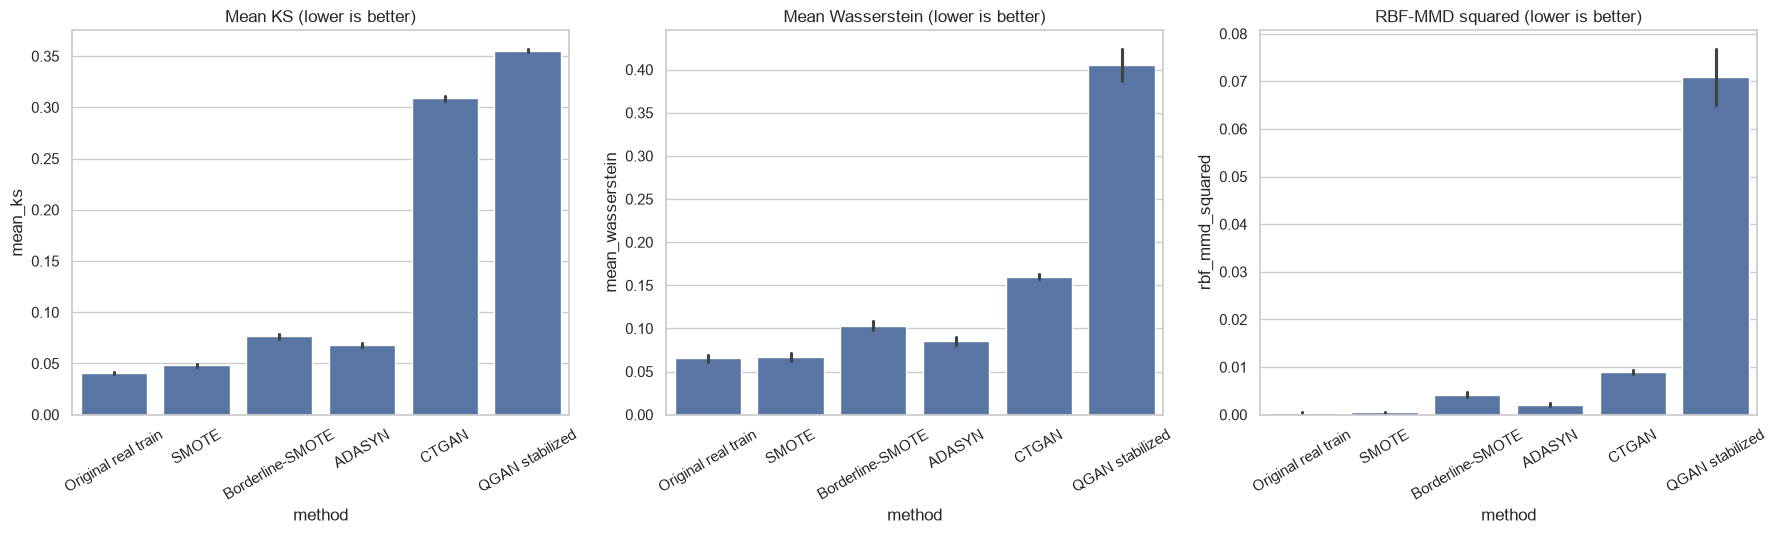

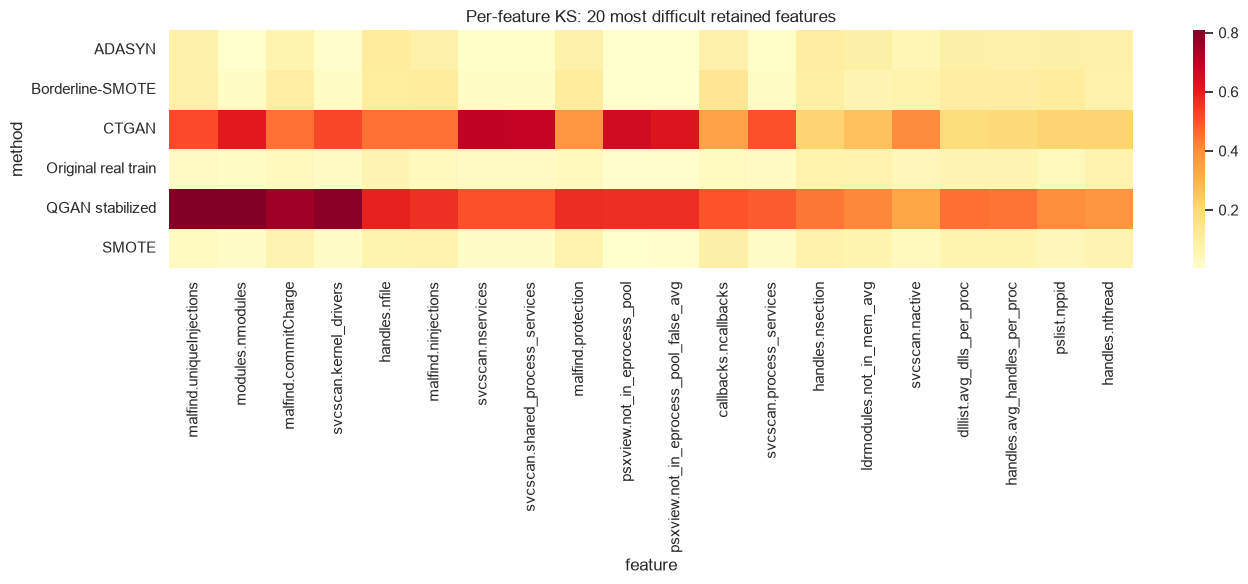

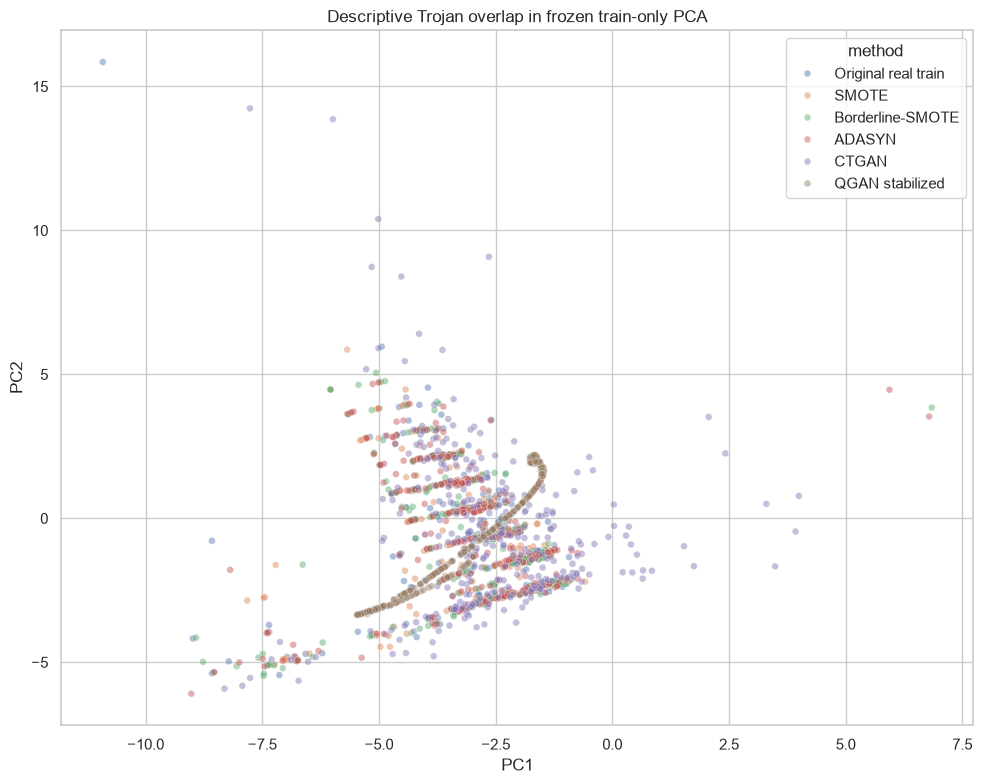

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, metric, title in zip(
    axes,
    ["mean_ks", "mean_wasserstein", "rbf_mmd_squared"],
    ["Mean KS", "Mean Wasserstein", "RBF-MMD squared"],
):
    sns.barplot(data=all_resamples, x="method", y=metric, ax=ax, errorbar=("ci", 95))
    ax.set_title(title + " (lower is better)"); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "01_common_fidelity_comparison.png", dpi=180); plt.show()

heat = component_metrics.groupby(["method", "feature"])["ks"].mean().unstack()
top_features = heat.mean().sort_values(ascending=False).head(20).index
plt.figure(figsize=(14, 6))
sns.heatmap(heat[top_features], cmap="YlOrRd")
plt.title("Per-feature KS: 20 most difficult retained features")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "02_feature_ks_heatmap.png", dpi=180); plt.show()

pca2 = PCA(n_components=2, random_state=SEED).fit(X_train)
plot_rows = []
for index, (method, (X_candidate, y_candidate)) in enumerate(candidates.items()):
    pool = X_candidate[y_candidate == "Trojan"]
    local = np.random.default_rng(SEED + index)
    chosen = pool[local.choice(len(pool), min(300, len(pool)), replace=False)]
    emb = pca2.transform(chosen)
    plot_rows.append(pd.DataFrame({"PC1": emb[:,0], "PC2": emb[:,1], "method": method}))
plot_frame = pd.concat(plot_rows, ignore_index=True)
plt.figure(figsize=(10, 8)); sns.scatterplot(
    data=plot_frame, x="PC1", y="PC2", hue="method", alpha=.45, s=24
); plt.title("Descriptive Trojan overlap in frozen train-only PCA")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "03_pca_overlap.png", dpi=180); plt.show()

## 5. Manifest and conclusions gate

In [9]:
manifest = {
    "protocol_version": "revalidation_v2_common_fidelity_v1",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "profile": PROFILE, "reportable": REPORTABLE,
    "dataset_sha256": EXPECTED_SHA256,
    "reference_partition": "validation",
    "candidate_methods": list(candidates),
    "minority_classes": MINORITY_CLASSES,
    "bootstrap_resamples": N_BOOTSTRAPS,
    "rows_per_class_per_resample_max": N_PER_CLASS,
    "rbf_gamma_frozen_from_real_training": gamma,
    "metrics": ["KS per feature", "Wasserstein per feature", "RBF-MMD squared"],
    "test_accessed": False,
    "winner_by_mean_rank": master.iloc[0]["method"],
    "warning": "Fidelity rank is not treated as downstream-utility rank.",
}
(OUTPUT_DIR / "fidelity_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print("FIDELITY STAGE ACCEPTED; TEST ACCESSED: False")

FIDELITY STAGE ACCEPTED; TEST ACCESSED: False
